<a href="https://colab.research.google.com/github/abdullahh-sheikhh/voxelmorph/blob/Test%2FJacobian/scripts/cell_tracking/train_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cell Deformation Estimation with VoxelMorph

2D deformable registration for PhC-C2DH-U373 cells using VoxelMorph, compared against Horn & Schunck classical optical flow baseline.

## 1. Setup

In [ ]:
!git clone https://github.com/abdullahh-sheikhh/voxelmorph.git
%cd voxelmorph
!git checkout Test/Jacobian
!pip install -e . -q
!pip install imagecodecs -q

Cloning into 'voxelmorph'...
remote: Enumerating objects: 6193, done.
remote: Counting objects: 100% (798/798), done.
remote: Compressing objects: 100% (130/130), done.
remote: Total 6193 (delta 742), reused 668 (delta 668), pack-reused 5395 (from 4)
Receiving objects: 100% (6193/6193), 237.67 MiB | 25.72 MiB/s, done.
Resolving deltas: 100% (3626/3626), done.
/content/voxelmorph
Already on 'dev'
Your branch is up to date with 'origin/dev'.
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
  Building editable for voxelmorph (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 80.5 MB/s eta 0:00:00


In [ ]:
import torch
print(f'PyTorch: {torch.__version__}')
print(f'CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch: 2.10.0+cu128
CUDA: True
GPU: Tesla T4


## 2. Download Dataset

In [ ]:
from pathlib import Path

!mkdir -p dataset

if not Path('dataset/train/01').exists():
    print('Downloading training data...')
    !wget -q https://data.celltrackingchallenge.net/training-datasets/PhC-C2DH-U373.zip -O dataset/train.zip
    !cd dataset && unzip -q train.zip -d train_raw && mv train_raw/PhC-C2DH-U373/* train/ && rm -rf train_raw train.zip
else:
    print('Training data already exists')

!echo "Train sequences:" && ls dataset/train/01/ | head -3 && echo "... (115 frames total)"

Training data already exists
Train sequences:
t000.tif
t001.tif
t002.tif
... (115 frames total)


## 3. Dataset Overview

What we are working with and what we are trying to do.

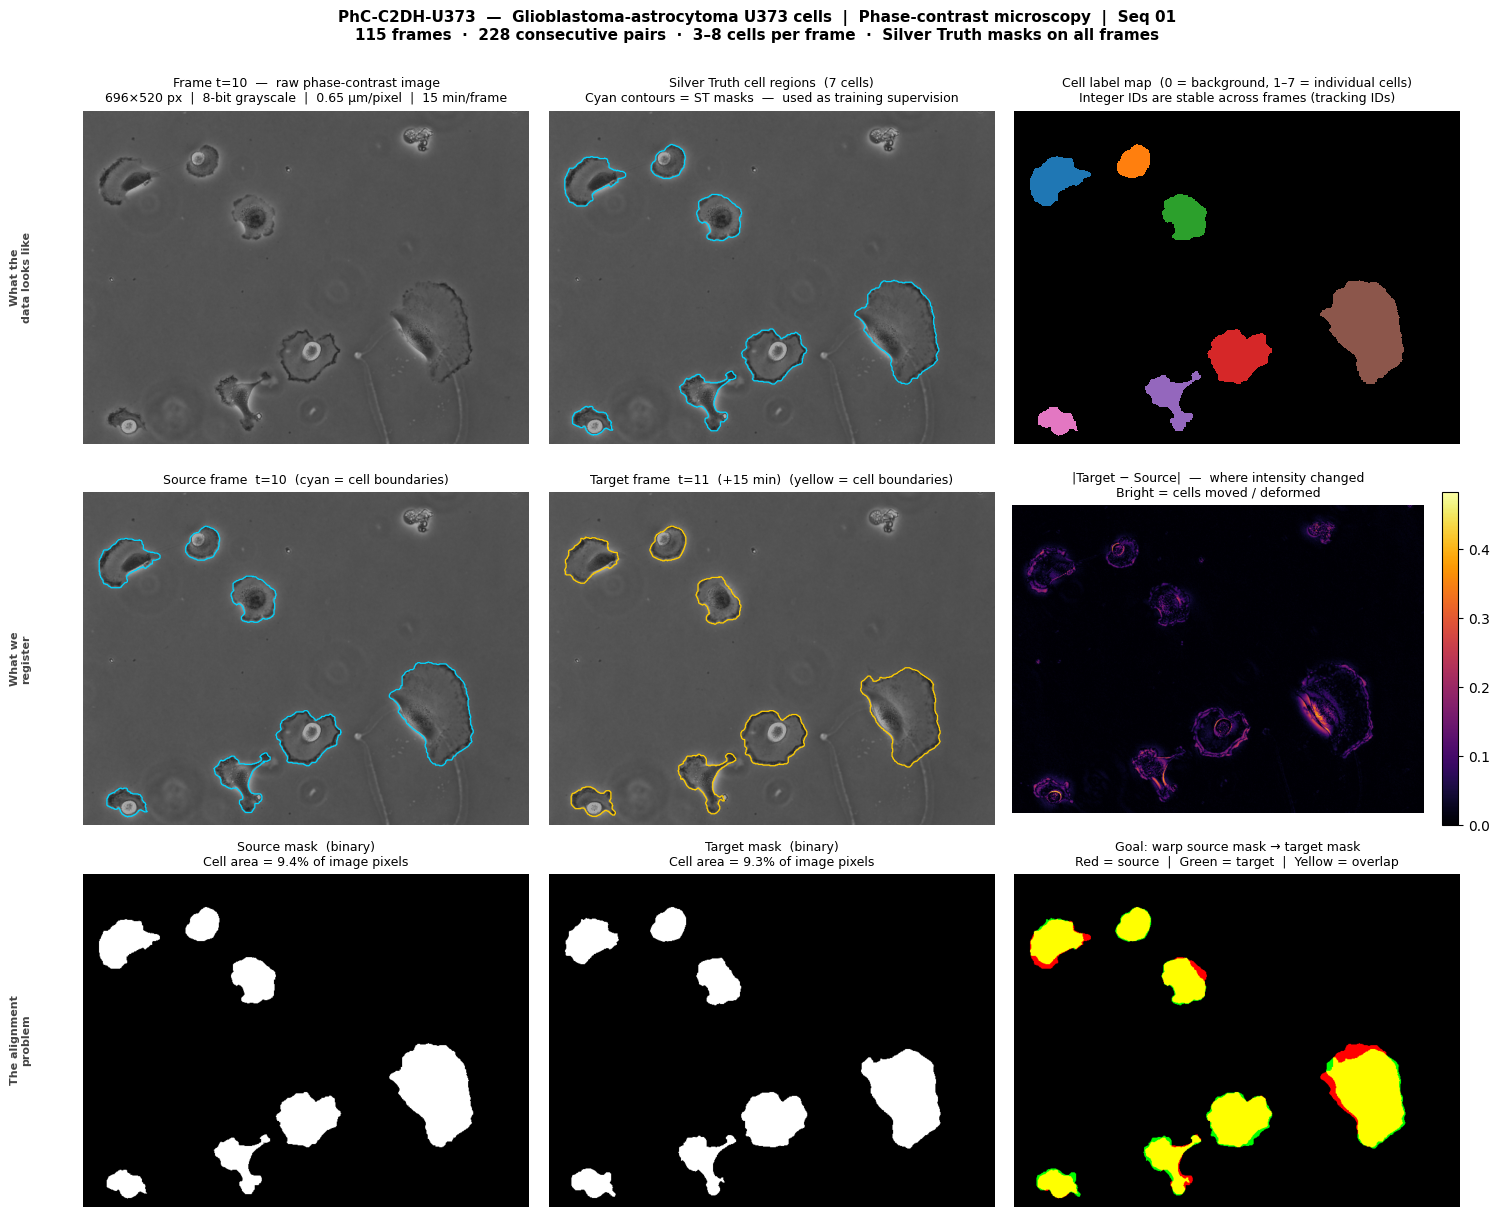

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import ListedColormap
from skimage import io
from pathlib import Path

#  Load two consecutive frames and their Silver Truth masks ─
frame_i, frame_j = 10, 11
seq_dir = Path('dataset/train/01')
st_dir  = Path('dataset/train/01_ST/SEG')

img_i  = io.imread(str(seq_dir / f't{frame_i:03d}.tif')).astype(np.float32) / 255.0
img_j  = io.imread(str(seq_dir / f't{frame_j:03d}.tif')).astype(np.float32) / 255.0
diff   = np.abs(img_j - img_i)

mask_i = io.imread(str(st_dir / f'man_seg{frame_i:03d}.tif')).astype(np.float32)
mask_j = io.imread(str(st_dir / f'man_seg{frame_j:03d}.tif')).astype(np.float32)

binary_i = mask_i > 0
binary_j = mask_j > 0
n_cells  = int(mask_i.max())

# Per-cell colour map: background = black, each cell = distinct colour
cell_cmap = ListedColormap(['black'] + [cm.tab10(i % 10) for i in range(n_cells)])

# Alignment overlay: red = source cells, green = target cells, yellow = overlap
align_rgb         = np.zeros((*img_i.shape, 3), dtype=np.float32)
align_rgb[..., 0] = binary_i.astype(float)
align_rgb[..., 1] = binary_j.astype(float)

#  Figure: 3 rows × 3 panels ─
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

kw_img = dict(cmap='gray', vmin=0, vmax=1)
kw_src = dict(colors=['#00d4ff'], linewidths=0.9, levels=[0.5])   # cyan  = source
kw_tgt = dict(colors=['#ffcc00'], linewidths=0.9, levels=[0.5])   # yellow = target

#  Row 0: single frame anatomy ─
axes[0, 0].imshow(img_i, **kw_img)
axes[0, 0].set_title(
    f'Frame t={frame_i}  —  raw phase-contrast image\n'
    f'696×520 px  |  8-bit grayscale  |  0.65 μm/pixel  |  15 min/frame', fontsize=9)

axes[0, 1].imshow(img_i, **kw_img)
axes[0, 1].contour(binary_i.astype(float), **kw_src)
axes[0, 1].set_title(
    f'Silver Truth cell regions  ({n_cells} cells)\n'
    f'Cyan contours = ST masks  —  used as training supervision', fontsize=9)

axes[0, 2].imshow(mask_i, cmap=cell_cmap, vmin=0, vmax=n_cells, interpolation='nearest')
axes[0, 2].set_title(
    f'Cell label map  (0 = background, 1–{n_cells} = individual cells)\n'
    f'Integer IDs are stable across frames (tracking IDs)', fontsize=9)

#  Row 1: consecutive pair
axes[1, 0].imshow(img_i, **kw_img)
axes[1, 0].contour(binary_i.astype(float), **kw_src)
axes[1, 0].set_title(f'Source frame  t={frame_i}  (cyan = cell boundaries)', fontsize=9)

axes[1, 1].imshow(img_j, **kw_img)
axes[1, 1].contour(binary_j.astype(float), **kw_tgt)
axes[1, 1].set_title(f'Target frame  t={frame_j}  (+15 min)  (yellow = cell boundaries)', fontsize=9)

im = axes[1, 2].imshow(diff, cmap='inferno', vmin=0, vmax=diff.max())
axes[1, 2].set_title('|Target − Source|  —  where intensity changed\nBright = cells moved / deformed', fontsize=9)
fig.colorbar(im, ax=axes[1, 2], fraction=0.046, pad=0.04)

#  Row 2: the registration problem ─
axes[2, 0].imshow(binary_i.astype(float), cmap='gray', vmin=0, vmax=1)
axes[2, 0].set_title(
    f'Source mask  (binary)\n'
    f'Cell area = {binary_i.mean()*100:.1f}% of image pixels', fontsize=9)

axes[2, 1].imshow(binary_j.astype(float), cmap='gray', vmin=0, vmax=1)
axes[2, 1].set_title(
    f'Target mask  (binary)\n'
    f'Cell area = {binary_j.mean()*100:.1f}% of image pixels', fontsize=9)

axes[2, 2].imshow(align_rgb)
axes[2, 2].set_title(
    'Goal: warp source mask → target mask\n'
    'Red = source  |  Green = target  |  Yellow = overlap', fontsize=9)

#  Row labels & final formatting ─
row_labels = ['What the\ndata looks like', 'What we\nregister', 'The alignment\nproblem']
for row, label in enumerate(row_labels):
    axes[row, 0].annotate(
        label, xy=(-0.14, 0.5), xycoords='axes fraction',
        ha='center', va='center', fontsize=8, fontweight='bold',
        rotation=90, color='#444444')

for ax in axes.flat:
    ax.axis('off')

plt.suptitle(
    'PhC-C2DH-U373  —  Glioblastoma-astrocytoma U373 cells  |  Phase-contrast microscopy  |  Seq 01\n'
    '115 frames  ·  228 consecutive pairs  ·  3–8 cells per frame  ·  Silver Truth masks on all frames',
    fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 4. Train — VM-1

Train **VM-1** (MSE loss, direct displacement) for 100 epochs.

All training runs use two mask-supervised loss terms:
- `--mask-weight 1.0` — soft Dice on Silver Truth cell masks (primary cell alignment signal)
- `--int-weight 0.1` — cell-restricted intensity loss (sub-cellular texture gradient)
- `--lambda` — displacement field smoothness regularisation

In [ ]:
!python -m scripts.cell_tracking.train \
    --data-dir dataset/train \
    --epochs 100 --batch-size 4 --lr 1e-4 \
    --loss mse --lambda 0.01 --int-steps 0 \
    --mask-weight 1.0 --int-weight 0.1 \
    --output-dir output/vm1 \
    --save-every 25

Device: cuda  |  Dataset: 228 pairs  |  Loss: MSE  |  int_steps: 0  |  lambda: 0.01

Epochs:   0% 0/100 [00:00<?, ?it/s]Epoch 1/100 — mask_dice: 0.097512
Epochs:   9% 9/100 [01:26<14:28,  9.55s/it]Epoch 10/100 — mask_dice: 0.088653
Epochs:  19% 19/100 [03:02<13:03,  9.67s/it]Epoch 20/100 — mask_dice: 0.073274
Epochs:  29% 29/100 [04:39<11:27,  9.68s/it]Epoch 30/100 — mask_dice: 0.064662
Epochs:  39% 39/100 [06:16<09:48,  9.64s/it]Epoch 40/100 — mask_dice: 0.059253
Epochs:  49% 49/100 [07:53<08:13,  9.67s/it]Epoch 50/100 — mask_dice: 0.054592
Epochs:  59% 59/100 [09:31<06:39,  9.75s/it]Epoch 60/100 — mask_dice: 0.051159
Epochs:  69% 69/100 [11:08<05:01,  9.72s/it]Epoch 70/100 — mask_dice: 0.048852
Epochs:  79% 79/100 [12:45<03:24,  9.72s/it]Epoch 80/100 — mask_dice: 0.045680
Epochs:  89% 89/100 [14:22<01:47,  9.73s/it]Epoch 90/100 — mask_dice: 0.043410
Epochs:  99% 99/100 [15:59<00:09,  9.67s/it]Epoch 100/100 — mask_dice: 0.040699
Epochs: 100% 100/100 [16:08<00:00,  9.69s/it]

Done. Bes

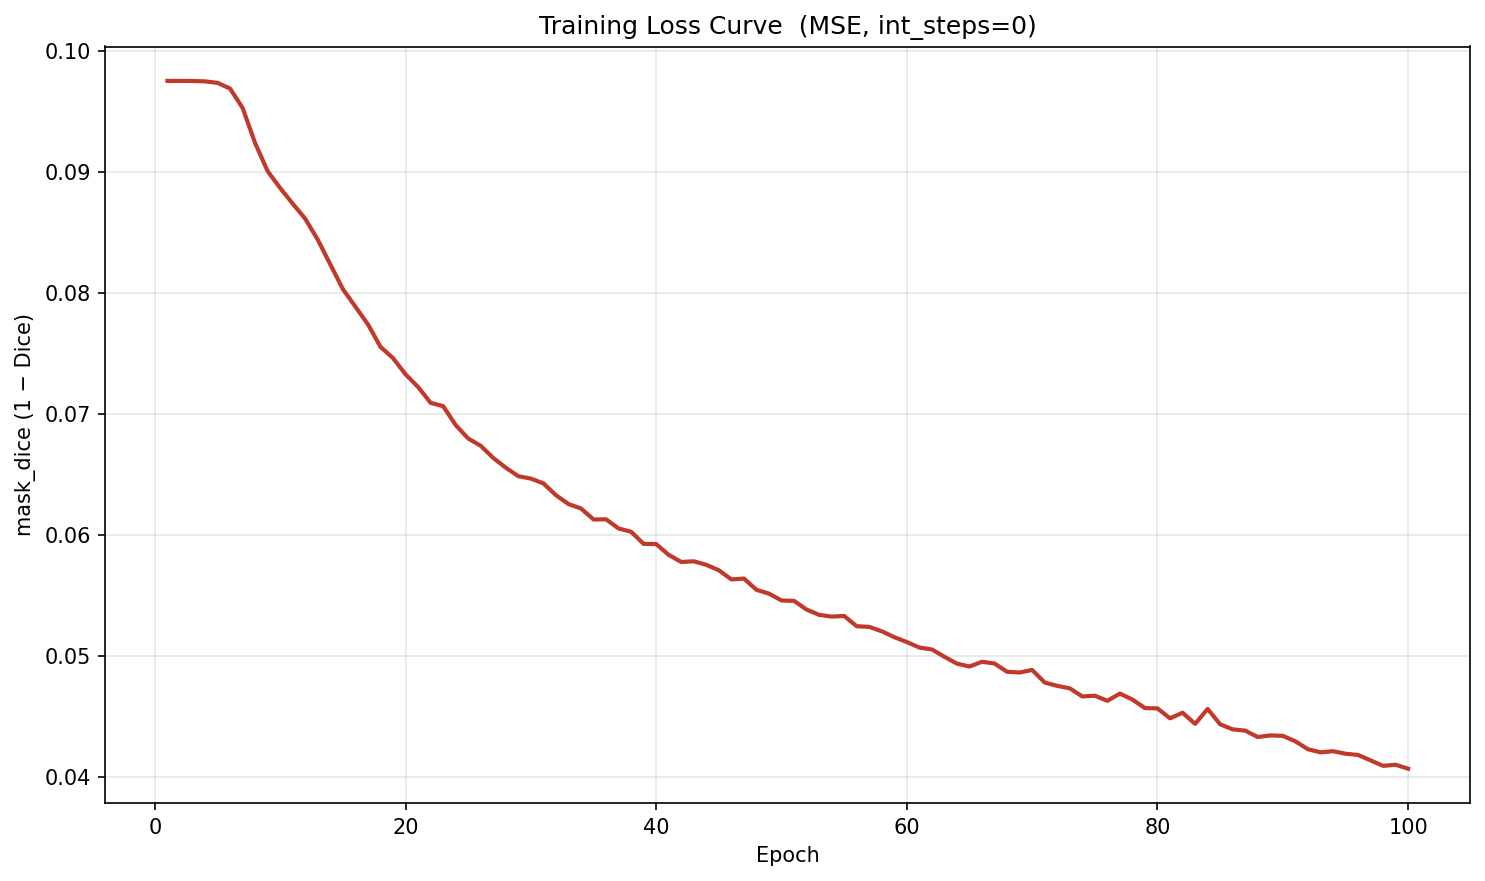

In [ ]:
from IPython.display import Image, display
display(Image(filename='output/vm1/loss_curve.png', width=800))

## 5. Evaluate — VM-1

Compute Dice score (primary), Jacobian determinant, per-cell deformation statistics, and runtime. Includes the Horn & Schunck baseline.

In [ ]:
!python -m scripts.cell_tracking.evaluate \
    --model output/vm1/best.pt \
    --data-dir dataset/train \
    --gt-dir dataset/train \
    --output-dir output/eval_vm1 \
    --max-pairs 0

Device: cuda
Pairs: 228, Baselines: True

Evaluating 228 pairs...

  Pair 0: Dice=0.7939, MaskedMSE=0.006977
  Pair 1: Dice=0.8210, MaskedMSE=0.004552
  Pair 2: Dice=0.7704, MaskedMSE=0.006937
  Pair 3: Dice=0.7587, MaskedMSE=0.006162
  Pair 4: Dice=0.8322, MaskedMSE=0.005529
  Pair 5: Dice=0.8076, MaskedMSE=0.005270
  Pair 6: Dice=0.8269, MaskedMSE=0.005142
  Pair 7: Dice=0.8489, MaskedMSE=0.004996
  Pair 8: Dice=0.7170, MaskedMSE=0.004722
  Pair 9: Dice=0.7887, MaskedMSE=0.004958
  Pair 10: Dice=0.8054, MaskedMSE=0.005640
  Pair 11: Dice=0.7891, MaskedMSE=0.004946
  Pair 12: Dice=0.8108, MaskedMSE=0.005761
  Pair 13: Dice=0.8204, MaskedMSE=0.005914
  Pair 14: Dice=0.8198, MaskedMSE=0.005968
  Pair 15: Dice=0.8342, MaskedMSE=0.006351
  Pair 16: Dice=0.7784, MaskedMSE=0.007832
  Pair 17: Dice=0.8207, MaskedMSE=0.007559
  Pair 18: Dice=0.8217, MaskedMSE=0.007255
  Pair 19: Dice=0.8388, MaskedMSE=0.005990
  Pair 20: Dice=0.7755, MaskedMSE=0.006706
  Pair 21: Dice=0.8044, MaskedMSE=0.0075


pair_0000.png


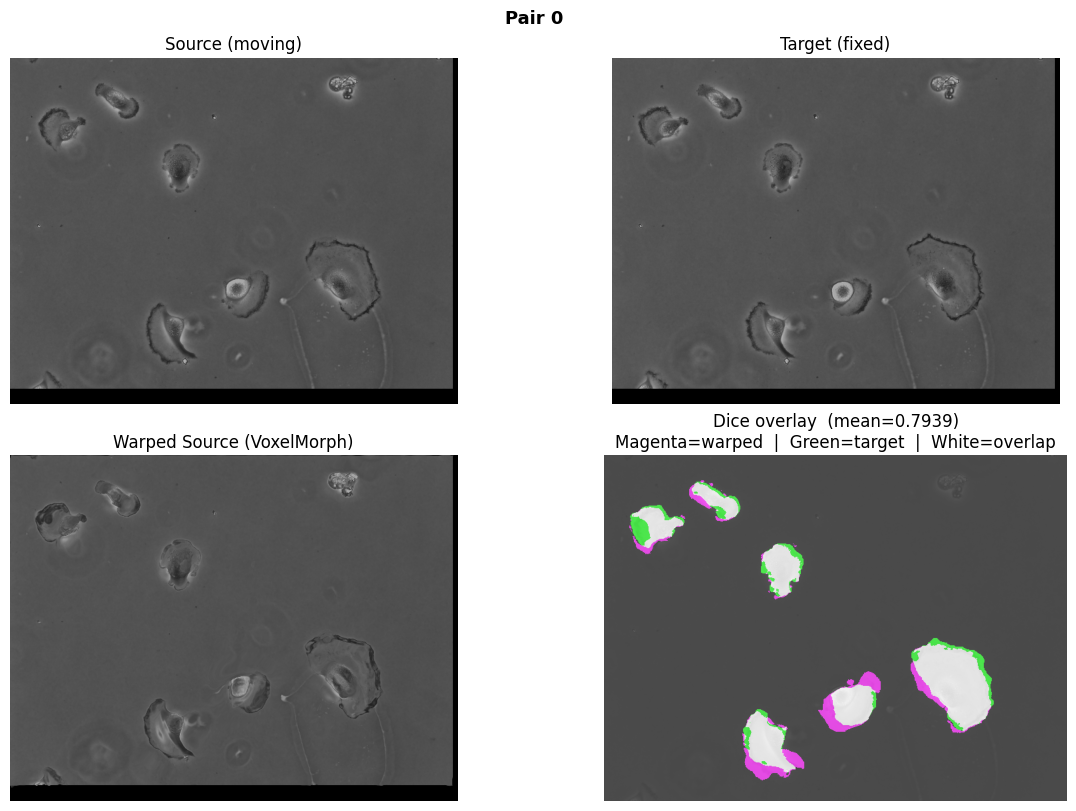


pair_0001.png


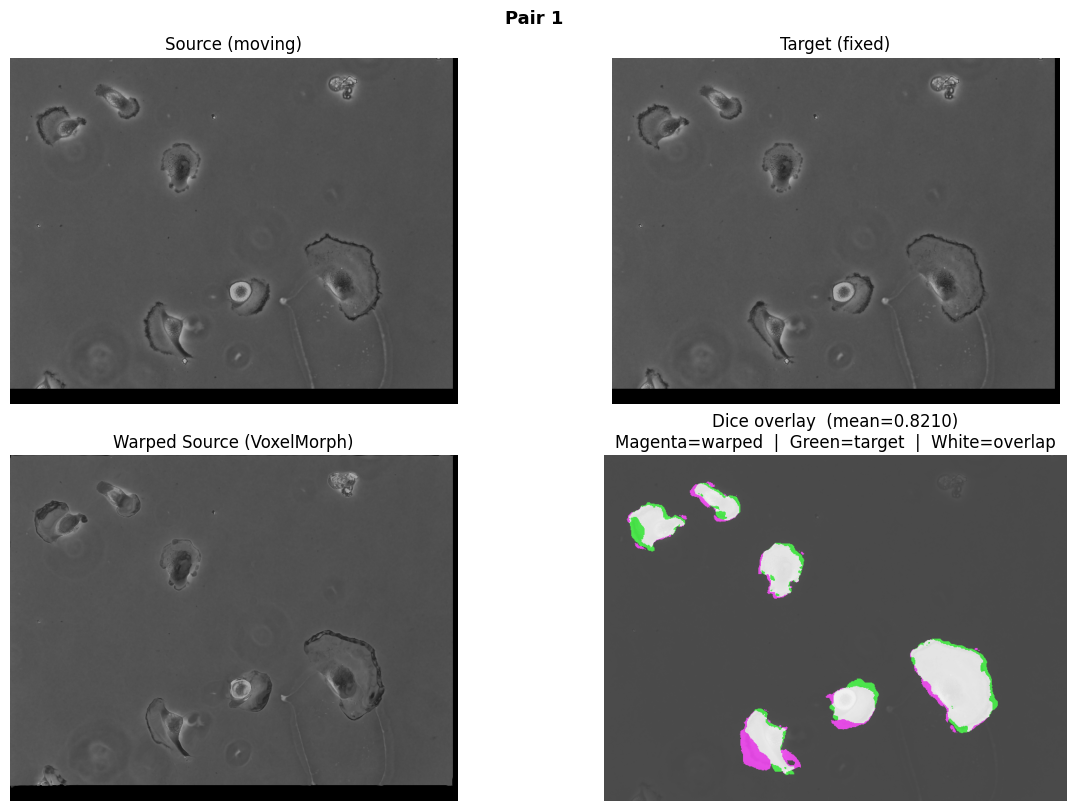


pair_0002.png


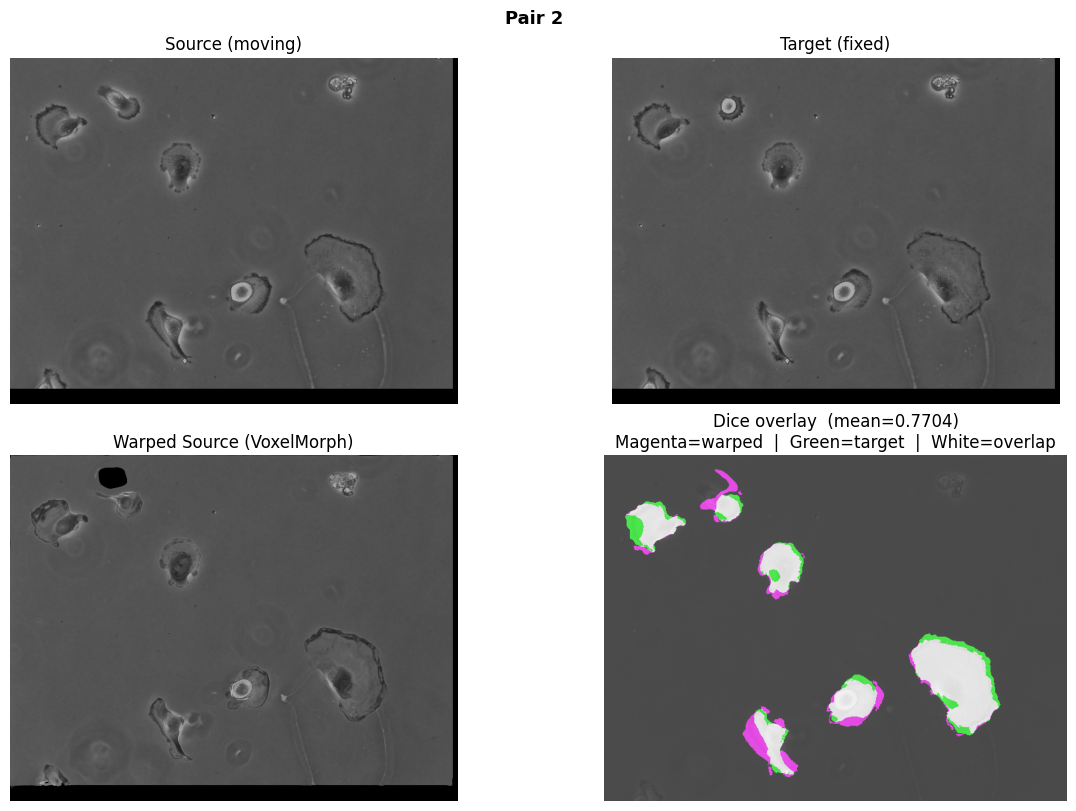


pair_0003.png


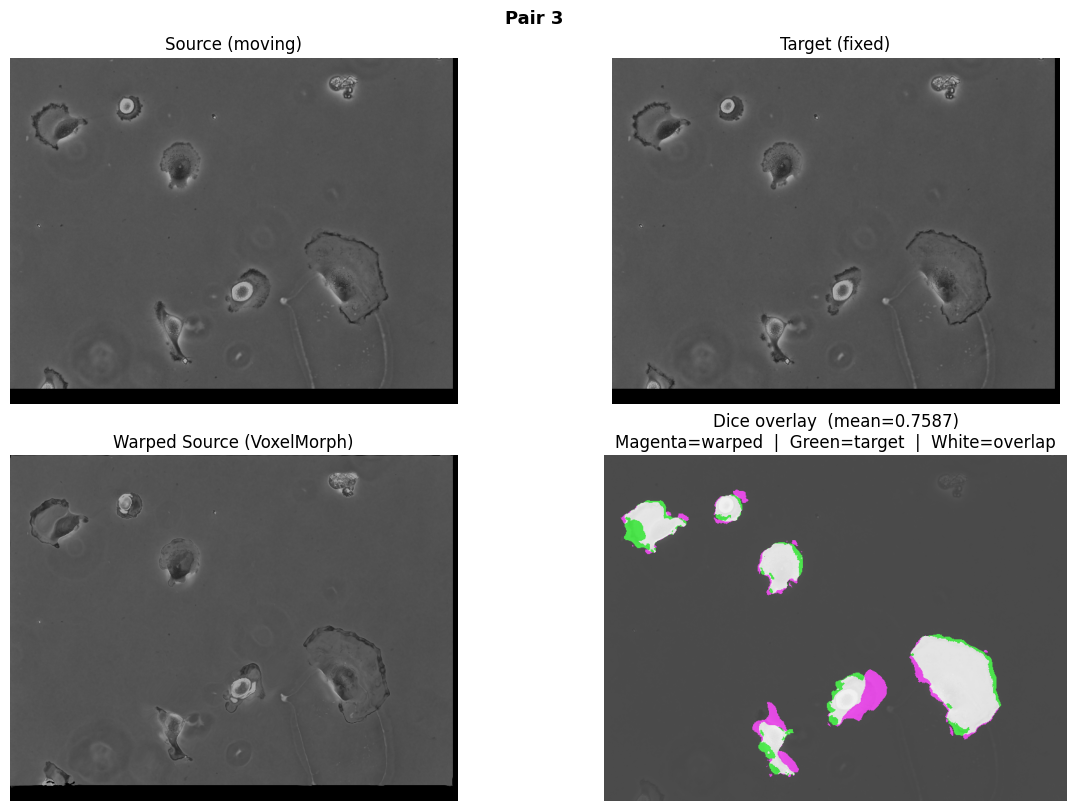


pair_0004.png


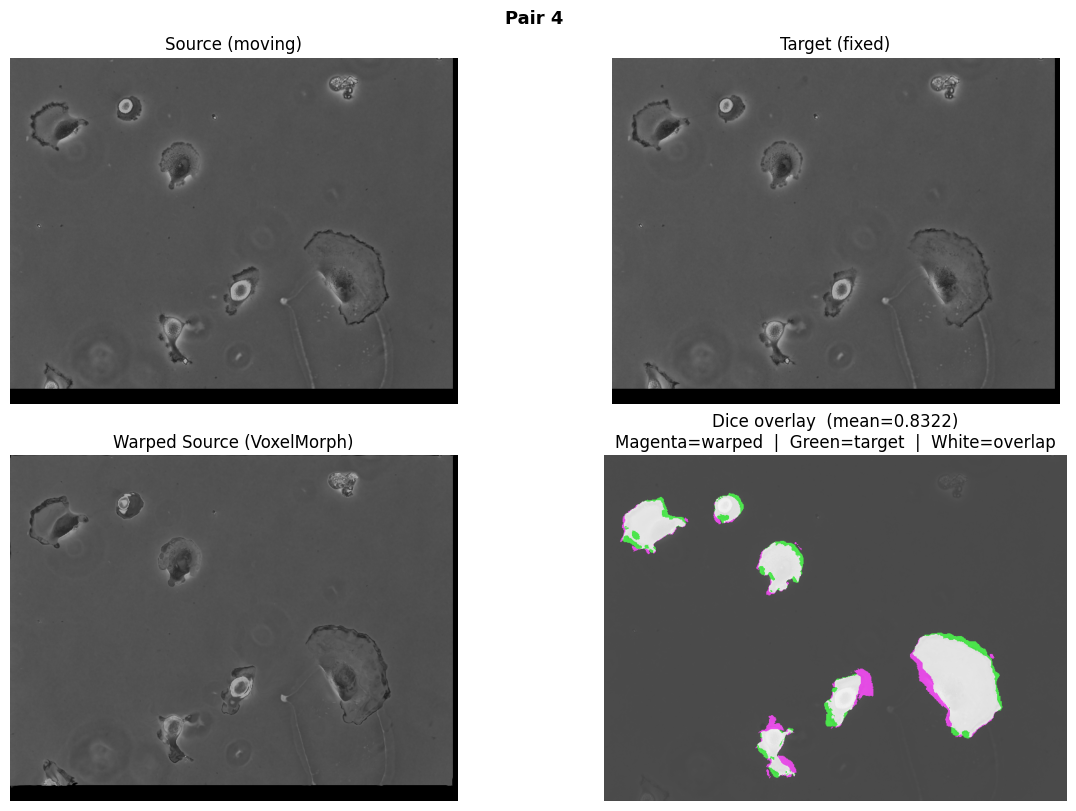

In [ ]:
from IPython.display import Image, display
from pathlib import Path

for img_path in sorted(Path('output/eval_vm1').glob('pair_*.png'))[:5]:
    print(f'\n{img_path.name}')
    display(Image(filename=str(img_path), width=900))

## 6. Variant Experiments

Train VM-2 (NCC, direct), VM-3 (MSE, diffeomorphic), VM-4 (NCC, diffeomorphic), then evaluate all four variants for the comparison table.

In [ ]:
# VM-2: NCC loss, direct displacement
!python -m scripts.cell_tracking.train \
    --data-dir dataset/train \
    --epochs 100 --batch-size 4 --lr 1e-4 \
    --loss ncc --lambda 1.0 --int-steps 0 \
    --mask-weight 1.0 --int-weight 0.1 \
    --output-dir output/vm2 \
    --save-every 25

Device: cuda  |  Dataset: 228 pairs  |  Loss: NCC  |  int_steps: 0  |  lambda: 1.0

Epochs:   0% 0/100 [00:00<?, ?it/s]Epoch 1/100 — mask_dice: 0.097512
Epochs:   9% 9/100 [01:37<16:09, 10.65s/it]Epoch 10/100 — mask_dice: 0.087569
Epochs:  19% 19/100 [03:23<14:22, 10.64s/it]Epoch 20/100 — mask_dice: 0.074630
Epochs:  29% 29/100 [05:07<12:17, 10.39s/it]Epoch 30/100 — mask_dice: 0.069375
Epochs:  39% 39/100 [06:50<10:29, 10.32s/it]Epoch 40/100 — mask_dice: 0.065430
Epochs:  49% 49/100 [08:34<08:47, 10.34s/it]Epoch 50/100 — mask_dice: 0.063059
Epochs:  59% 59/100 [10:17<07:04, 10.36s/it]Epoch 60/100 — mask_dice: 0.060613
Epochs:  69% 69/100 [12:01<05:21, 10.39s/it]Epoch 70/100 — mask_dice: 0.058383
Epochs:  79% 79/100 [13:45<03:39, 10.47s/it]Epoch 80/100 — mask_dice: 0.057180
Epochs:  89% 89/100 [15:30<01:54, 10.43s/it]Epoch 90/100 — mask_dice: 0.054946
Epochs:  99% 99/100 [17:15<00:10, 10.51s/it]Epoch 100/100 — mask_dice: 0.053677
Epochs: 100% 100/100 [17:25<00:00, 10.46s/it]

Done. Best

In [ ]:
# VM-3: MSE loss, diffeomorphic (integration steps = 7)
!python -m scripts.cell_tracking.train \
    --data-dir dataset/train \
    --epochs 100 --batch-size 4 --lr 1e-4 \
    --loss mse --lambda 0.01 --int-steps 7 \
    --mask-weight 1.0 --int-weight 0.1 \
    --output-dir output/vm3 \
    --save-every 25

Device: cuda  |  Dataset: 228 pairs  |  Loss: MSE  |  int_steps: 7  |  lambda: 0.01

Epochs:   0% 0/100 [00:00<?, ?it/s]Epoch 1/100 — mask_dice: 0.097511
Epochs:   9% 9/100 [01:36<16:16, 10.73s/it]Epoch 10/100 — mask_dice: 0.082385
Epochs:  19% 19/100 [03:23<14:23, 10.67s/it]Epoch 20/100 — mask_dice: 0.073984
Epochs:  29% 29/100 [05:10<12:38, 10.68s/it]Epoch 30/100 — mask_dice: 0.065244
Epochs:  39% 39/100 [06:57<10:53, 10.71s/it]Epoch 40/100 — mask_dice: 0.060101
Epochs:  49% 49/100 [08:44<09:02, 10.64s/it]Epoch 50/100 — mask_dice: 0.054804
Epochs:  59% 59/100 [10:31<07:19, 10.71s/it]Epoch 60/100 — mask_dice: 0.051097
Epochs:  69% 69/100 [12:18<05:32, 10.72s/it]Epoch 70/100 — mask_dice: 0.048290
Epochs:  79% 79/100 [14:05<03:45, 10.75s/it]Epoch 80/100 — mask_dice: 0.045783
Epochs:  89% 89/100 [15:53<01:58, 10.75s/it]Epoch 90/100 — mask_dice: 0.044646
Epochs:  99% 99/100 [17:40<00:10, 10.76s/it]Epoch 100/100 — mask_dice: 0.043068
Epochs: 100% 100/100 [17:51<00:00, 10.71s/it]

Done. Bes

In [ ]:
# VM-4: NCC loss, diffeomorphic (integration steps = 7)
!python -m scripts.cell_tracking.train \
    --data-dir dataset/train \
    --epochs 100 --batch-size 4 --lr 1e-4 \
    --loss ncc --lambda 1.0 --int-steps 7 \
    --mask-weight 1.0 --int-weight 0.1 \
    --output-dir output/vm4 \
    --save-every 25

Device: cuda  |  Dataset: 228 pairs  |  Loss: NCC  |  int_steps: 7  |  lambda: 1.0

Epochs:   0% 0/100 [00:00<?, ?it/s]Epoch 1/100 — mask_dice: 0.097512
Epochs:   9% 9/100 [01:41<17:01, 11.23s/it]Epoch 10/100 — mask_dice: 0.082906
Epochs:  19% 19/100 [03:33<15:08, 11.21s/it]Epoch 20/100 — mask_dice: 0.074676
Epochs:  29% 29/100 [05:26<13:18, 11.24s/it]Epoch 30/100 — mask_dice: 0.068911
Epochs:  39% 39/100 [07:18<11:24, 11.22s/it]Epoch 40/100 — mask_dice: 0.065624
Epochs:  49% 49/100 [09:10<09:28, 11.14s/it]Epoch 50/100 — mask_dice: 0.063195
Epochs:  59% 59/100 [11:03<07:40, 11.22s/it]Epoch 60/100 — mask_dice: 0.061126
Epochs:  69% 69/100 [12:55<05:50, 11.30s/it]Epoch 70/100 — mask_dice: 0.058985
Epochs:  79% 79/100 [14:48<03:56, 11.25s/it]Epoch 80/100 — mask_dice: 0.057484
Epochs:  89% 89/100 [16:39<02:02, 11.16s/it]Epoch 90/100 — mask_dice: 0.055581
Epochs:  99% 99/100 [18:31<00:11, 11.17s/it]Epoch 100/100 — mask_dice: 0.054667
Epochs: 100% 100/100 [18:42<00:00, 11.22s/it]

Done. Best


VM-1 (MSE, direct)


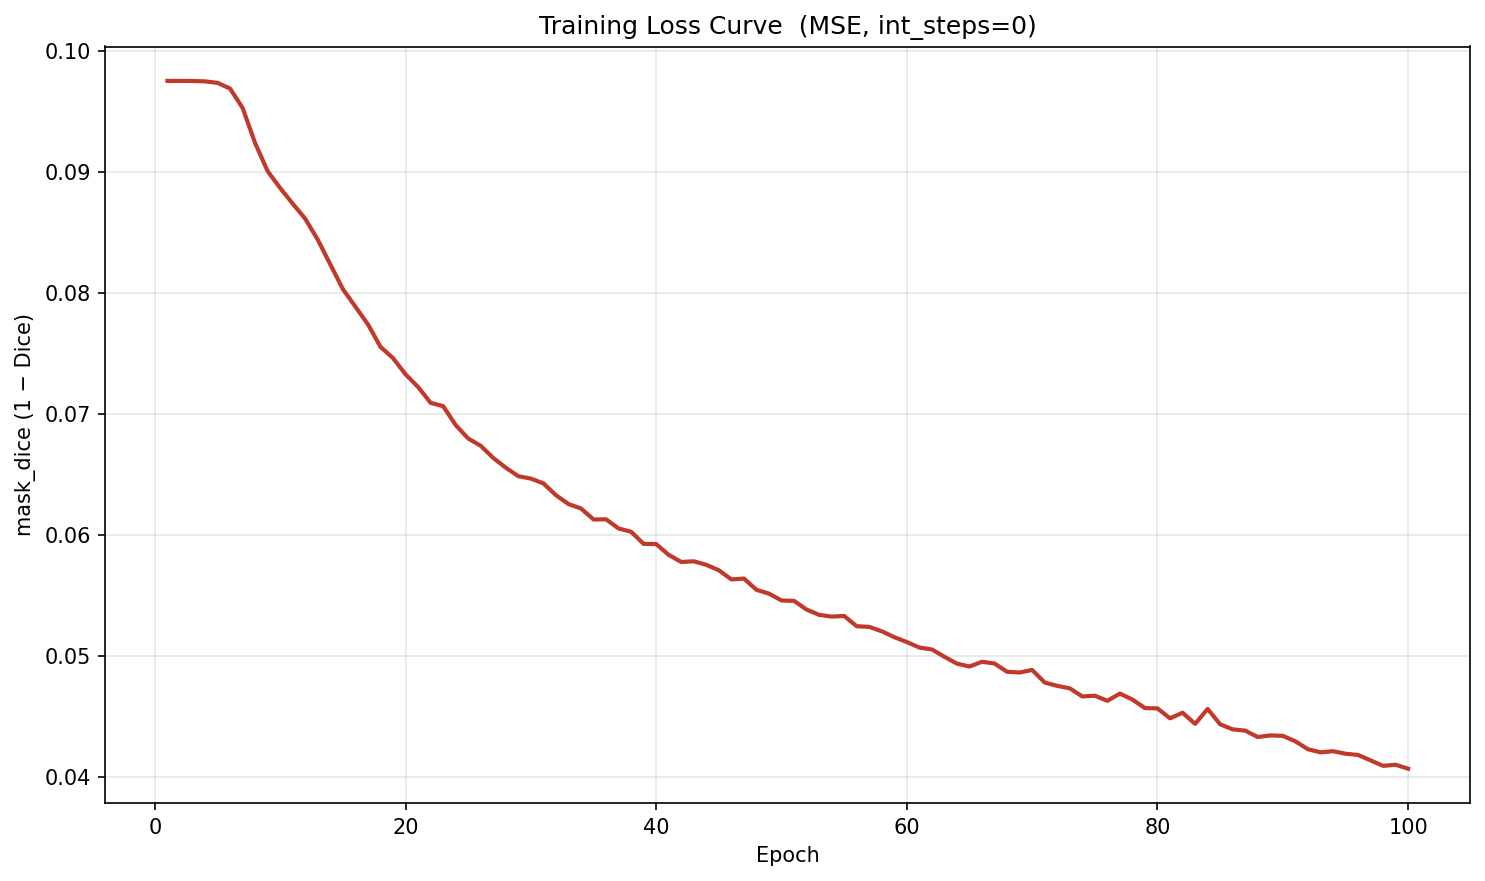


VM-2 (NCC, direct)


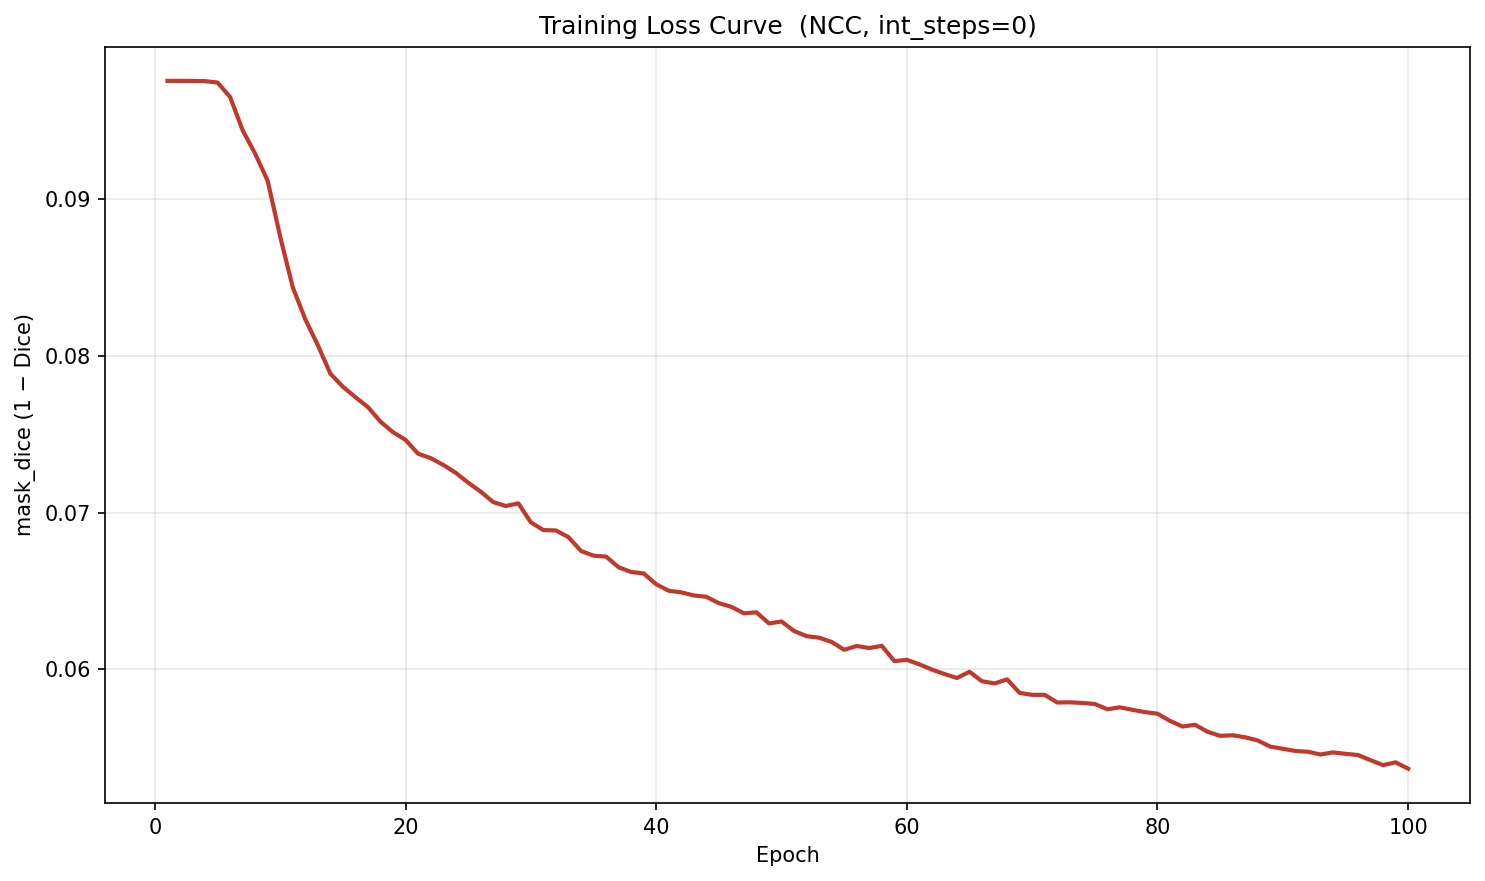


VM-3 (MSE, diffeomorphic)


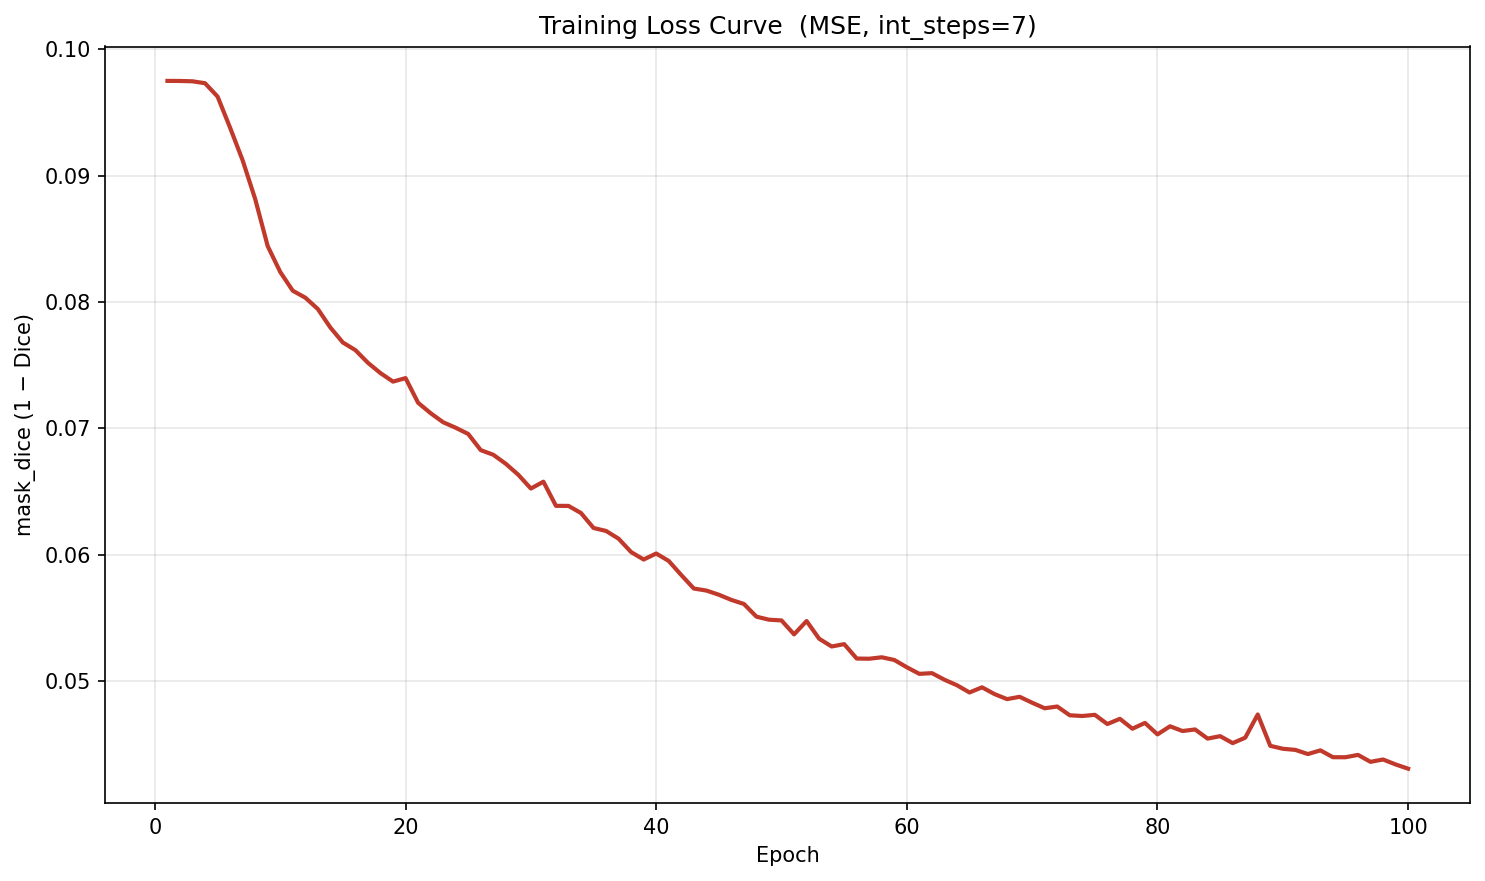


VM-4 (NCC, diffeomorphic)


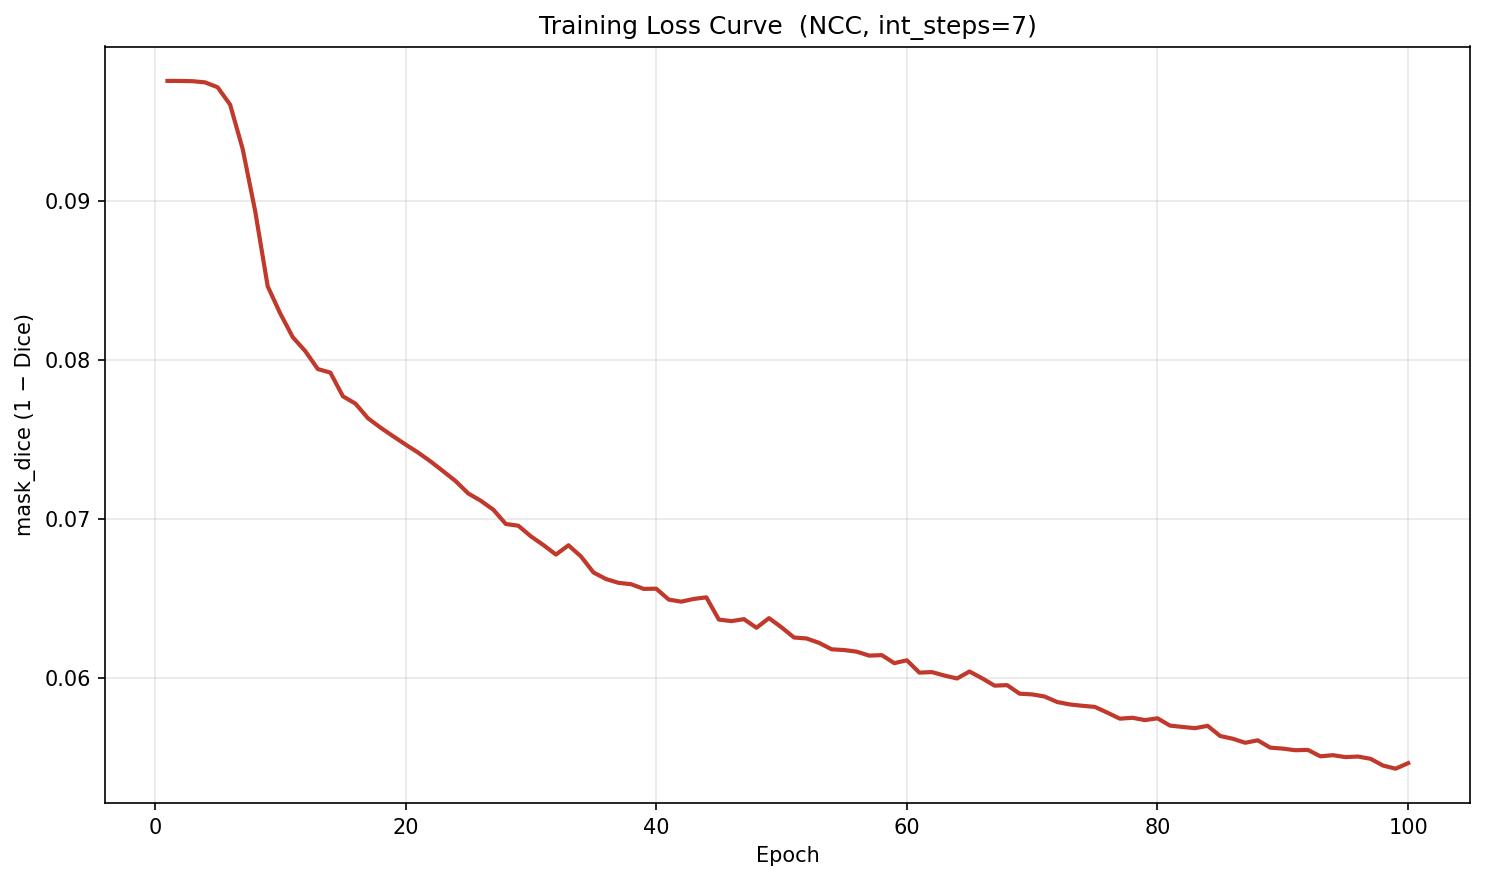

In [ ]:
from IPython.display import Image, display
from pathlib import Path

for name, d in [('VM-1 (MSE, direct)',        'output/vm1'),
                ('VM-2 (NCC, direct)',        'output/vm2'),
                ('VM-3 (MSE, diffeomorphic)', 'output/vm3'),
                ('VM-4 (NCC, diffeomorphic)', 'output/vm4')]:
    p = Path(d) / 'loss_curve.png'
    if p.exists():
        print(f'\n{name}')
        display(Image(filename=str(p), width=700))

In [ ]:
from pathlib import Path

variants = {
    'VM-1 (MSE, direct)':        ('output/vm1/best.pt', 0, 'output/eval_vm1'),
    'VM-2 (NCC, direct)':        ('output/vm2/best.pt', 0, 'output/eval_vm2'),
    'VM-3 (MSE, diffeomorphic)': ('output/vm3/best.pt', 7, 'output/eval_vm3'),
    'VM-4 (NCC, diffeomorphic)': ('output/vm4/best.pt', 7, 'output/eval_vm4'),
}

for name, (model_path, int_steps, eval_dir) in variants.items():
    if not Path(model_path).exists():
        print(f'Skipping {name}: {model_path} not found')
        continue
    print(f'\nEvaluating {name}...')
    !python -m scripts.cell_tracking.evaluate \
        --model {model_path} \
        --data-dir dataset/train \
        --gt-dir dataset/train \
        --int-steps {int_steps} \
        --output-dir {eval_dir} \
        --no-baselines \
        --max-pairs 0


Evaluating VM-1 (MSE, direct)...
Device: cuda
Pairs: 228, Baselines: False

Evaluating 228 pairs...

  Pair 0: Dice=0.7939, MaskedMSE=0.006977
  Pair 1: Dice=0.8210, MaskedMSE=0.004552
  Pair 2: Dice=0.7704, MaskedMSE=0.006937
  Pair 3: Dice=0.7587, MaskedMSE=0.006162
  Pair 4: Dice=0.8322, MaskedMSE=0.005529
  Pair 5: Dice=0.8076, MaskedMSE=0.005270
  Pair 6: Dice=0.8269, MaskedMSE=0.005142
  Pair 7: Dice=0.8489, MaskedMSE=0.004996
  Pair 8: Dice=0.7170, MaskedMSE=0.004722
  Pair 9: Dice=0.7887, MaskedMSE=0.004958
  Pair 10: Dice=0.8054, MaskedMSE=0.005640
  Pair 11: Dice=0.7891, MaskedMSE=0.004946
  Pair 12: Dice=0.8108, MaskedMSE=0.005761
  Pair 13: Dice=0.8204, MaskedMSE=0.005914
  Pair 14: Dice=0.8198, MaskedMSE=0.005968
  Pair 15: Dice=0.8342, MaskedMSE=0.006351
  Pair 16: Dice=0.7784, MaskedMSE=0.007832
  Pair 17: Dice=0.8207, MaskedMSE=0.007559
  Pair 18: Dice=0.8217, MaskedMSE=0.007255
  Pair 19: Dice=0.8388, MaskedMSE=0.005990
  Pair 20: Dice=0.7755, MaskedMSE=0.006706
  Pai

In [ ]:
import json
import pandas as pd
from pathlib import Path

def load(path, key):
    p = Path(path)
    return json.loads(p.read_text()).get(key) if p.exists() else None

def fmt(m):
    return {
        'Dice':        f"{m['dice_mean']:.4f} ± {m['dice_std']:.4f}" if 'dice_mean' in m else '—',
        'Masked MSE':  f"{m['masked_mse_mean']:.6f} ± {m['masked_mse_std']:.6f}" if 'masked_mse_mean' in m else '—',
        'Jac Det':     f"{m['jac_det_mean']:.4f}" if 'jac_det_mean' in m else '—',
        'Neg Frac':    f"{m['jac_neg_frac_mean']:.4f}" if 'jac_neg_frac_mean' in m else '—',
        'Runtime (s)': f"{m['runtime_mean']:.4f}" if 'runtime_mean' in m else '—',
    }

rows = []

hs = load('output/eval_vm1/metrics.json', 'horn_schunck')
if hs:
    rows.append({'Method': 'Horn & Schunck', **fmt(hs)})

for name, d in [('VM-1 (MSE, direct)',        'output/eval_vm1'),
                ('VM-2 (NCC, direct)',        'output/eval_vm2'),
                ('VM-3 (MSE, diffeomorphic)', 'output/eval_vm3'),
                ('VM-4 (NCC, diffeomorphic)', 'output/eval_vm4')]:
    m = load(f'{d}/metrics.json', 'vxm')
    if m:
        rows.append({'Method': name, **fmt(m)})

pd.DataFrame(rows).set_index('Method')

,Dice,Masked MSE,Runtime (s)
Method,,,
"VM-1 (MSE, direct)",0.7848 ± 0.0548,0.006702 ± 0.001314,0.0104
"VM-2 (NCC, direct)",0.8495 ± 0.0517,0.004000 ± 0.001051,0.0103
"VM-3 (MSE, diffeomorphic)",0.8422 ± 0.0542,0.006480 ± 0.001181,0.0128
"VM-4 (NCC, diffeomorphic)",0.8327 ± 0.0515,0.003794 ± 0.001024,0.0128


## 7. Download Results

In [ ]:
# from google.colab import files
# !zip -r results.zip output/ 2>/dev/null; true
# files.download('results.zip')